In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.shape

(7043, 21)

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

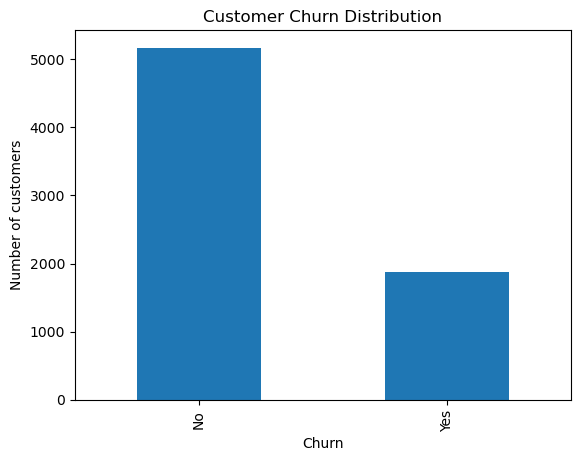

In [6]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")

plt.show()

### The dataset of Telco_customer_churn has 7043 customers

 So I have determined that only 5174 of these customers did not leave the service(NO-Churn), while the rest the 1869 customers left the services. 
 This info shows that about 26% customers left, which is a very high number, so it shows/suggests potential challenges in customer retention.
 



In [7]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


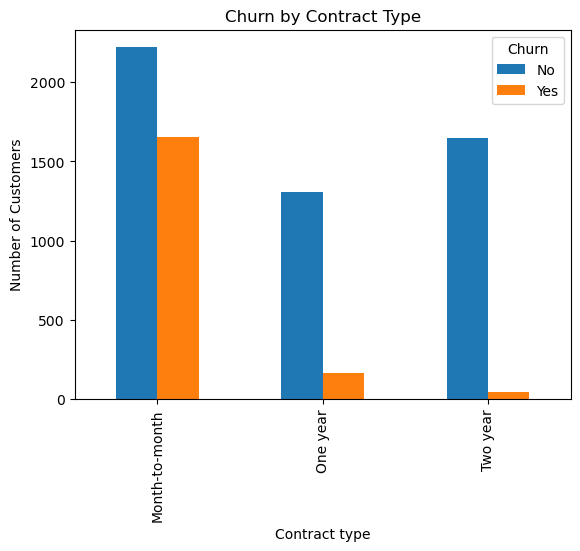

In [8]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title("Churn by Contract Type")
plt.xlabel("Contract type")
plt.ylabel("Number of Customers")

plt.show()

### Infomation about Churn by Contract types the customers use/choose 

This shows the Customers that have month to month contracts with longer contracts stay longer than those that dont.
It shows that the contracts for one and two years have customers that stayed and used the Telco service 

<Figure size 640x480 with 0 Axes>

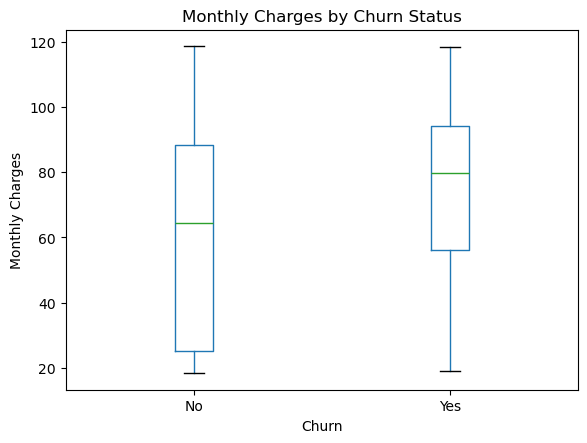

In [9]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.grid(False)

plt.show()

### Monthly Charges for Churn 

This boxplot shows us that the customers who stayed(No-churn) have less monthly charges , than the ones that left(yes-churn).
This suggests the the increased in charges are likely linked to the churn of customers( in and out in different seasons)

<Figure size 640x480 with 0 Axes>

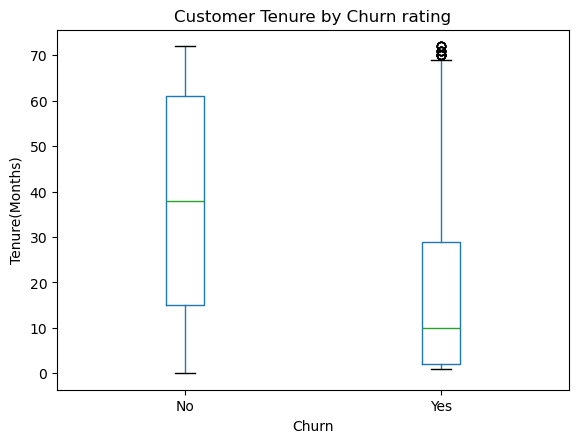

In [10]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="tenure", by="Churn")

plt.title("Customer Tenure by Churn rating")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure(Months)")

plt.grid(False)
plt.show()


### Tenure(monthly) analysis 
This graph shows us the monthly analysis of customers that stay for longer months and who leaves the company/services
This suggests that customer tend to leave in the earlier stages of thir signing uo with the company

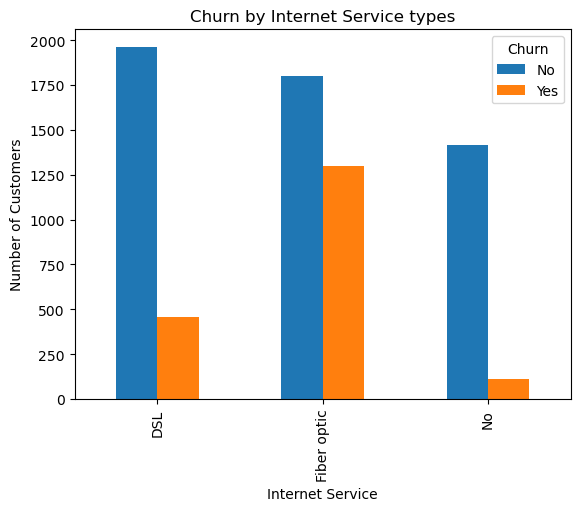

In [11]:
import matplotlib.pyplot as plt

df.groupby(['InternetService','Churn']).size().unstack().plot(kind='bar')

plt.title("Churn by Internet Service types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.grid(False)
plt.show()

### Internet service information 

Customers using fibre internet appear to leave the company more frequently than those that use a DSL or dont use internet services

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0})

### above explained 
This code converts the Churn column from text values (Yes/No) into numbers (1 to 10). This is important because numerical values are required for correlation analysis and machine learning 

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

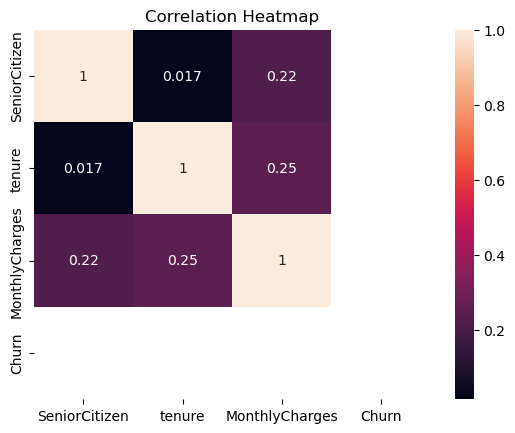

In [16]:
import seaborn as sns 

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Explanation
This code creates a heatmap that shows the relationship(correlations)between numerical variables in the dataset.The values inside the heatmap indicate how strongly variables are related to each other. 

### Conclusion and Recommandations 

The analysis of the customer churn dataset reveals several key patterns. 
Customers on month-to-month contracts are more likely to churn compared to those on long-term contracts. 
Customers with higher monthly charges also show a higher tendency to churn. 
Additionally, customers with shorter tenure are more likely to leave, indicating that churn is more common among newer customers. 
Fiber optic internet users also appear to have a higher churn rate compared to other service types.

### Recommendations

Based on these insights, the company can take the following actions:

- Encourage customers to switch to long-term contracts by offering incentives or discounts.
- Review pricing strategies, especially for higher monthly charges, to ensure customers perceive value.
- Improve onboarding and customer experience for new customers to reduce early churn.
- Investigate potential issues with fiber optic services, such as pricing or service quality.

These actions can help improve customer retention and reduce churn.

##### This project demonstrates how exploratory data analysis can be used to identify key factors influencing customer churn and support data-driven decision-making.